## Human-in-the-Loop — Pause, Review, Resume in LangGraph


In [1]:
from typing import TypedDict


# --- 1. STATE ---
class State(TypedDict):
    request: str
    draft_action: str
    human_approved: bool
    result: str

In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")


# --- 2. NODES ---
def plan_node(state: State) -> dict:
    resp = llm.invoke([HumanMessage(f"User wants: '{state['request']}'. Write a one-sentence action plan.")])
    print(f"[plan] Draft: {resp.content}")
    return {"draft_action": resp.content}


def execute_node(state: State) -> dict:
    if state["human_approved"]:
        return {"result": f"✅ EXECUTED: {state['draft_action']}"}
    return {"result": "❌ REJECTED by human reviewer."}

In [3]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


# --- 3. GRAPH WITH interrupt_before ---
builder = StateGraph(State)
builder.add_node("plan", plan_node)
builder.add_node("execute", execute_node)
builder.add_edge(START, "plan")
builder.add_edge("plan", "execute")
builder.add_edge("execute", END)

checkpointer = MemorySaver()
# interrupt_before pauses execution BEFORE the named node runs
graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["execute"],
)

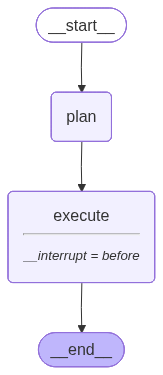

In [4]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# --- 5. Test and Run ---
cfg_a = {"configurable": {"thread_id": "demo_a"}}
graph.invoke(
    {
        "request": "Send welcome email to yash@code.com",
        "draft_action": "",
        "human_approved": False,
        "result": "",
    },
    config=cfg_a,
)
snap = graph.get_state(cfg_a)
print(f"⏸️  Paused before: {snap.next}")
print(f"   state: {snap.values}")

human_input = input("Human Input: ")  # human in the loop input
human_input = True if human_input == "True" else False

graph.update_state(cfg_a, {"human_approved": human_input})
final = graph.invoke(None, config=cfg_a)
print(f"🏁 {final['result']}, {final['human_approved']}")

[plan] Draft: Send a welcome email to yash@code.com to introduce our services and provide any necessary information.
⏸️  Paused before: ('execute',)
   state: {'request': 'Send welcome email to yash@code.com', 'draft_action': 'Send a welcome email to yash@code.com to introduce our services and provide any necessary information.', 'human_approved': False, 'result': ''}
🏁 ❌ REJECTED by human reviewer., False
